# Small Car Price Prediction

This project predicts the selling price of used cars using machine learning models such as Linear Regression and Lasso Regression.

## Objective
The goal is to build a regression model that can estimate the selling price of a car based on features like year, present price, kilometers driven, fuel type, seller type, transmission, and owner count.

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn import metrics
import pickle

## Data Collection and Initial Exploration

In [171]:
car_dataset = pd.read_csv("data/small_car_data.csv")

### Dataset Overview
Let us inspect the first few rows and understand the shape and structure of the dataset.

### Categorical Feature Distribution
We will check the frequency of categorical values before encoding them.

In [172]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [173]:
car_dataset.shape

(301, 9)

In [174]:
# getting some information about he dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [175]:
# checking the missing values
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [176]:
# checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [177]:
# encoding the categorical data
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
car_dataset.replace({"Transmission":{"Manual":0,"Automatic":1}},inplace=True)

/tmp/ipykernel_5982/2164017746.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
/tmp/ipykernel_5982/2164017746.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
/tmp/ipykernel_5982/2164017746.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=

In [178]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [179]:
car_dataset.shape

(301, 9)

Splitting the data and Target

In [180]:
car_dataset['Car_Age'] = 2026 - car_dataset['Year']

In [181]:
X = car_dataset.drop(['Car_Name', 'Selling_Price', 'Year'], axis=1)
Y = car_dataset['Selling_Price']

In [182]:
print(X.shape)
print(Y.shape)

(301, 7)
(301,)


In [183]:
X.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,5.59,27000,0,0,0,0,12
1,9.54,43000,1,0,0,0,13
2,9.85,6900,0,0,0,0,9
3,4.15,5200,0,0,0,0,15
4,6.87,42450,1,0,0,0,12


In [184]:
Y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


## Exploratory Data Analysis
We will visualize important relationships in the data before training the models.

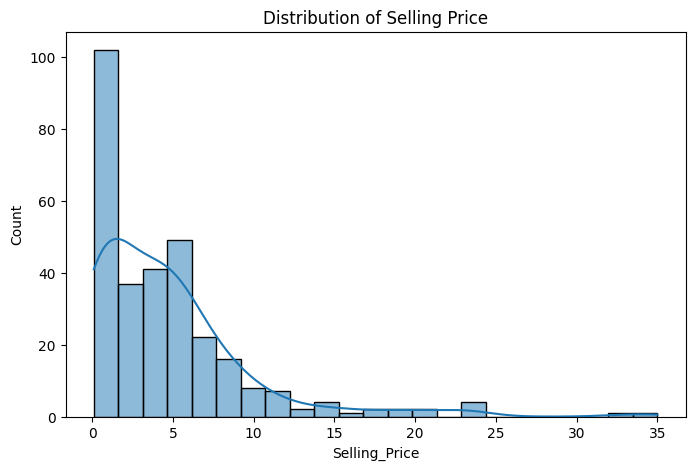

In [185]:
plt.figure(figsize=(8, 5))
sns.histplot(car_dataset['Selling_Price'], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

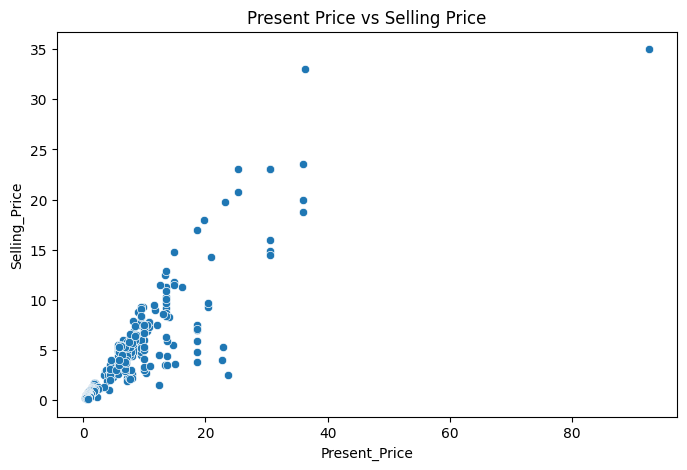

In [186]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=car_dataset)
plt.title("Present Price vs Selling Price")
plt.show()

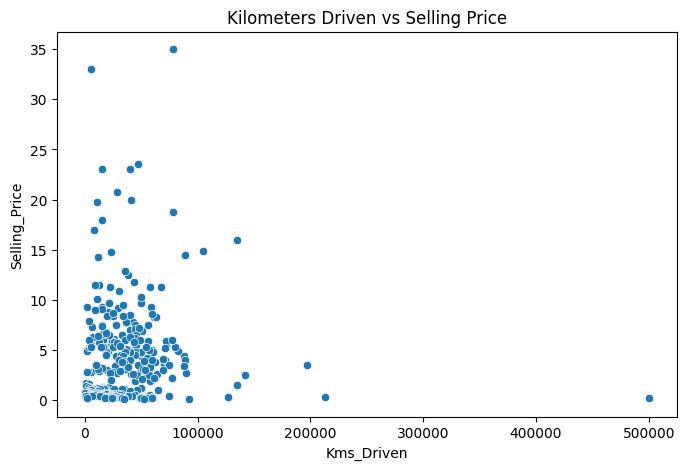

In [187]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=car_dataset)
plt.title("Kilometers Driven vs Selling Price")
plt.show()

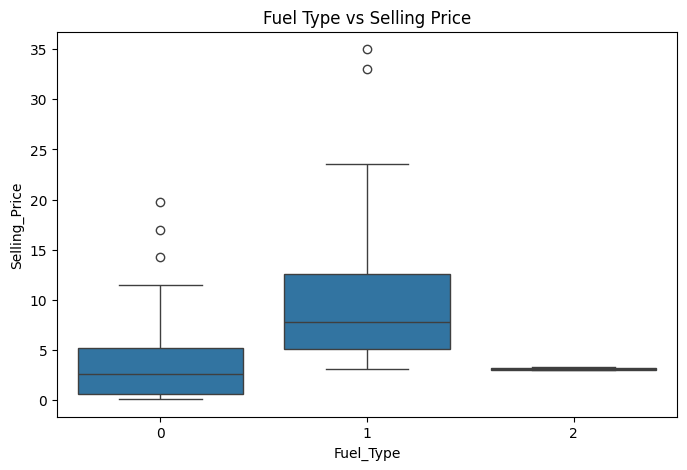

In [188]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=car_dataset)
plt.title("Fuel Type vs Selling Price")
plt.show()

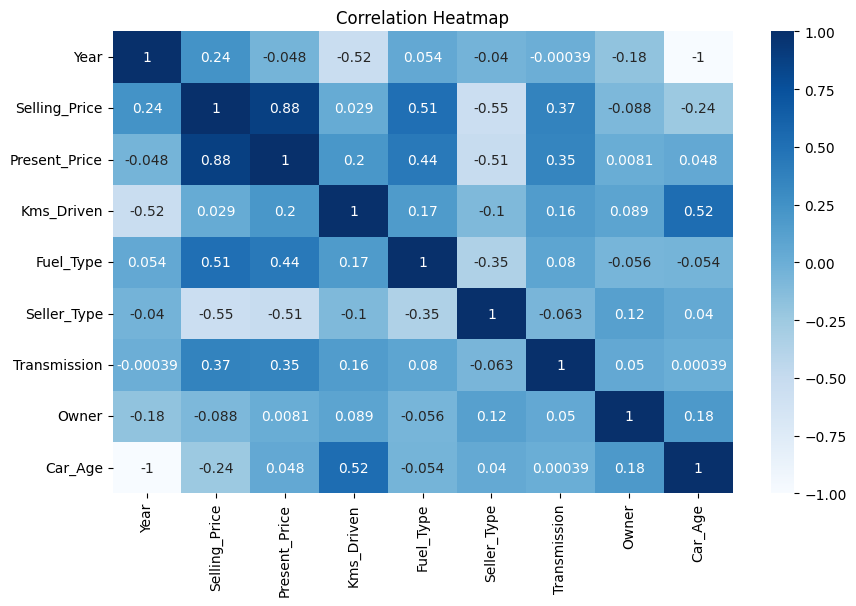

In [189]:
plt.figure(figsize=(10, 6))
sns.heatmap(car_dataset.drop(columns=['Car_Name']).corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

Splitting Training and Test data

In [190]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

Model Training

1. Linear Regression

In [191]:
lin_reg_model = LinearRegression()

In [192]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [193]:
training_data_prediction = lin_reg_model.predict(X_train)

In [194]:
print("Linear Regression - Training Metrics")
print("MAE :", mean_absolute_error(Y_train, training_data_prediction))
print("MSE :", mean_squared_error(Y_train, training_data_prediction))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, training_data_prediction)))
print("R2  :", r2_score(Y_train, training_data_prediction))

Linear Regression - Training Metrics
MAE : 1.1761077496260213
MSE : 3.0672445262787904
RMSE: 1.7513550543161687
R2  : 0.8839793496750796


In [195]:
test_data_prediction = lin_reg_model.predict(X_test)

In [196]:
print("Linear Regression - Test Metrics")
print("MAE :", mean_absolute_error(Y_test, test_data_prediction))
print("MSE :", mean_squared_error(Y_test, test_data_prediction))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, test_data_prediction)))
print("R2  :", r2_score(Y_test, test_data_prediction))

Linear Regression - Test Metrics
MAE : 1.2217615462332647
MSE : 3.5289272538906142
RMSE: 1.8785439185418622
R2  : 0.8468053957657442


Visualize the actual prices and Predicted prices

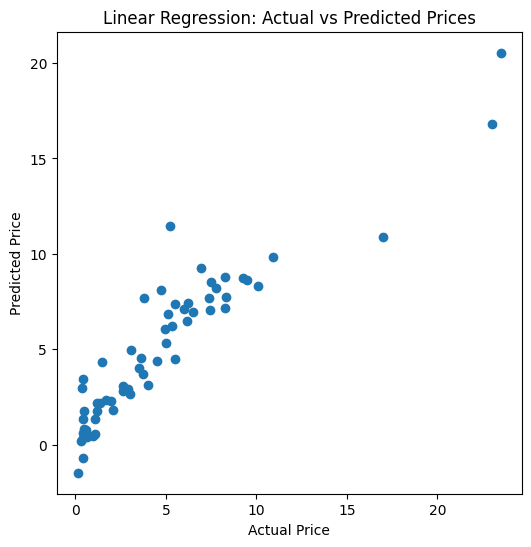

In [197]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.show()

2. Lasso Regression

In [198]:
lass_reg_model = Lasso()

In [199]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

Model Evaluation

In [200]:
# prediction on Training data
train_pred_lasso = lass_reg_model.predict(X_train)

In [201]:
print("Lasso Regression - Training Metrics")
print("MAE :", mean_absolute_error(Y_train, train_pred_lasso))
print("MSE :", mean_squared_error(Y_train, train_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, train_pred_lasso)))
print("R2  :", r2_score(Y_train, train_pred_lasso))

Lasso Regression - Training Metrics
MAE : 1.2231102166379946
MSE : 4.017621775508359
RMSE: 2.004400602551386
R2  : 0.8480306714510464


In [202]:
test_pred_lasso = lass_reg_model.predict(X_test)

In [203]:
print("Lasso Regression - Test Metrics")
print("MAE :", mean_absolute_error(Y_test, test_pred_lasso))
print("MSE :", mean_squared_error(Y_test, test_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, test_pred_lasso)))
print("R2  :", r2_score(Y_test, test_pred_lasso))

Lasso Regression - Test Metrics
MAE : 1.4714179283504272
MSE : 4.640429535826082
RMSE: 2.1541656240470655
R2  : 0.7985538621024055


Visualize the actual prices and Predicted prices

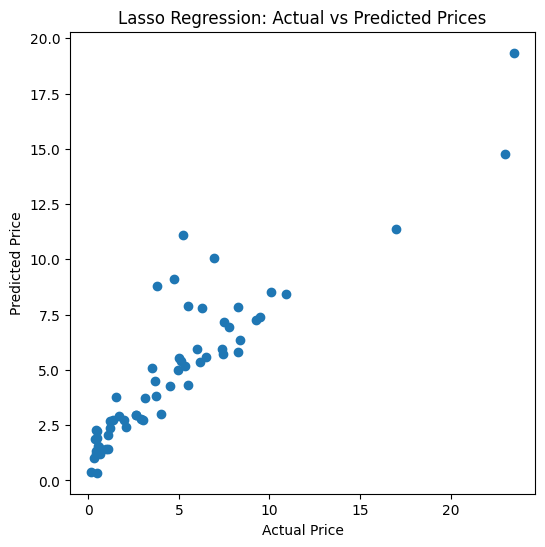

In [204]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, test_pred_lasso)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted Prices")
plt.show()

In [205]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression"],
    "Train R2": [
        r2_score(Y_train, training_data_prediction),
        r2_score(Y_train, train_pred_lasso)
    ],
    "Test R2": [
        r2_score(Y_test, test_data_prediction),
        r2_score(Y_test, test_pred_lasso)
    ],
    "Test MAE": [
        mean_absolute_error(Y_test, test_data_prediction),
        mean_absolute_error(Y_test, test_pred_lasso)
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(Y_test, test_data_prediction)),
        np.sqrt(mean_squared_error(Y_test, test_pred_lasso))
    ]
})

results

,Model,Train R2,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.883979,0.846805,1.221762,1.878544
1,Lasso Regression,0.848031,0.798554,1.471418,2.154166


In [206]:
input_data = (X.iloc[1])

input_data_as_numpy = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy.reshape(1,-1)

prediction = lass_reg_model.predict(input_data_reshaped)

print(prediction)

[5.44488657]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


## Conclusion

In this project, a used car price prediction model was built using machine learning.

- The dataset was cleaned and categorical features were encoded.
- A new feature, **Car_Age**, was created from the manufacturing year.
- Two regression models were trained: **Linear Regression** and **Lasso Regression**.
- Based on test performance, **Lasso Regression performed better** and was selected as the final model.
- This model can be used in a simple prediction application such as a Streamlit web app.